In [3]:
from cadetgui.widgets import ConfigurationWidget, SolutionWidget
from CADETProcess.simulator import Cadet


%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from collections.abc import Mapping
from CADETProcess.fields import Field
import numpy as np

def solution_to_fields_lenmatch_v3(res):
    """
    Flatten res.solution (unit -> {port -> SolutionIO}) into
    { "unit:port": Field }, using:
      data := io.solution (numpy array, with (T,1) -> (T,))
      time := try unit-level 'time'/'t' (incl. {'values': ...}) of length T,
              else try global (res.solution) same way, else np.arange(T).
    """
    solmap = getattr(res, "solution", None)
    if not isinstance(solmap, Mapping):
        return res

    def _safe_arr(x):
        try:
            return np.asarray(x)
        except Exception:
            try:
                return np.asarray(list(x))
            except Exception:
                return None

    def _as_vector(x):
        """Extract 1D vector from common wrappers (dict with 'values', obj.values, or array-like)."""
        if x is None:
            return None
        if isinstance(x, Mapping) and "values" in x:
            return _safe_arr(x["values"])
        vals = getattr(x, "values", None)
        if vals is not None and not callable(vals):
            return _safe_arr(vals)
        return _safe_arr(x)

    def _find_time(scope: Mapping, T: int):
        # 1) direct 'time'/'t'
        for key in ("time", "t"):
            if key in scope:
                cand = _as_vector(scope[key])
                if cand is not None and cand.ndim == 1 and cand.size == T:
                    return cand
        # 2) nested holders like {'time': {'values': ...}}
        for k, v in scope.items():
            if isinstance(v, Mapping) and "values" in v:
                cand = _safe_arr(v["values"])
                if cand is not None and cand.ndim == 1 and cand.size == T:
                    return cand
        # 3) any 1D array of length T
        for k, v in scope.items():
            cand = _as_vector(v)
            if cand is not None and cand.ndim == 1 and cand.size == T:
                return cand
        return None

    out = {}

    for unit, ports in solmap.items():
        if not isinstance(ports, Mapping):
            continue
        for port, io in ports.items():
            data = getattr(io, "solution", None)
            data = _safe_arr(data)
            if data is None or data.ndim < 1:
                continue

            # squeeze trailing singleton (T,1) -> (T,)
            if data.ndim >= 2 and data.shape[-1] == 1:
                data = data[..., 0]

            T = int(data.shape[0])
            if T <= 1:
                continue

            # time (per port): unit → global → arange
            t = _find_time(ports, T)
            if t is None:
                t = _find_time(solmap, T)
            if t is None:
                t = np.arange(T)

            coords = {"time": (t, "s")}

            # treat last dim as components if >1 and small-ish
            comp_names = None
            if data.ndim >= 2 and 1 < data.shape[-1] <= 64:
                comp_names = [f"C{i}" for i in range(data.shape[-1])]

            try:
                out[f"{unit}:{port}"] = Field(
                    coordinates=coords,
                    data=data,
                    components=comp_names,
                    name=f"{unit}:{port}",
                )
            except Exception:
                # Skip malformed, keep others
                pass

    return out if out else solmap




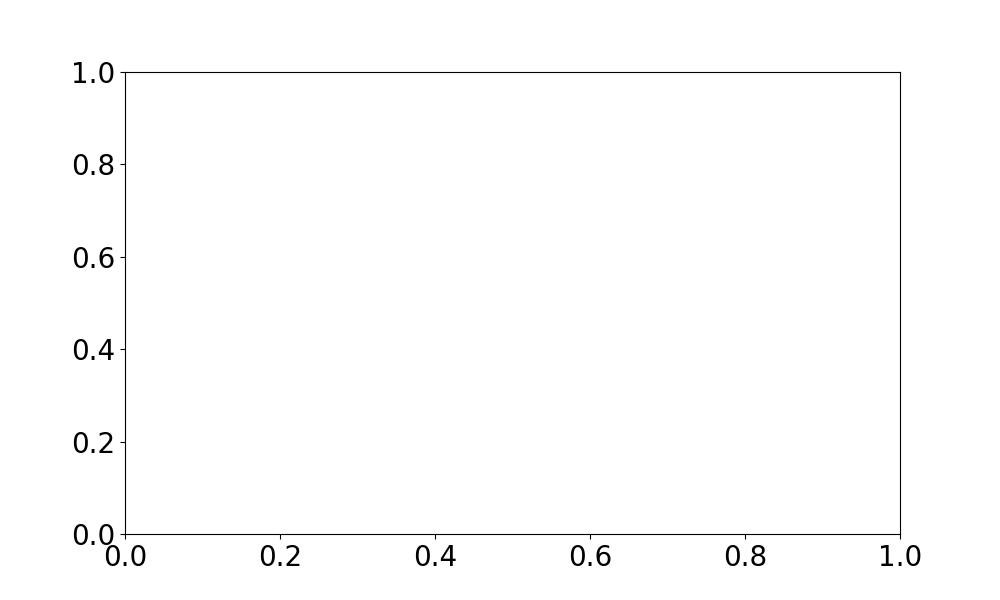

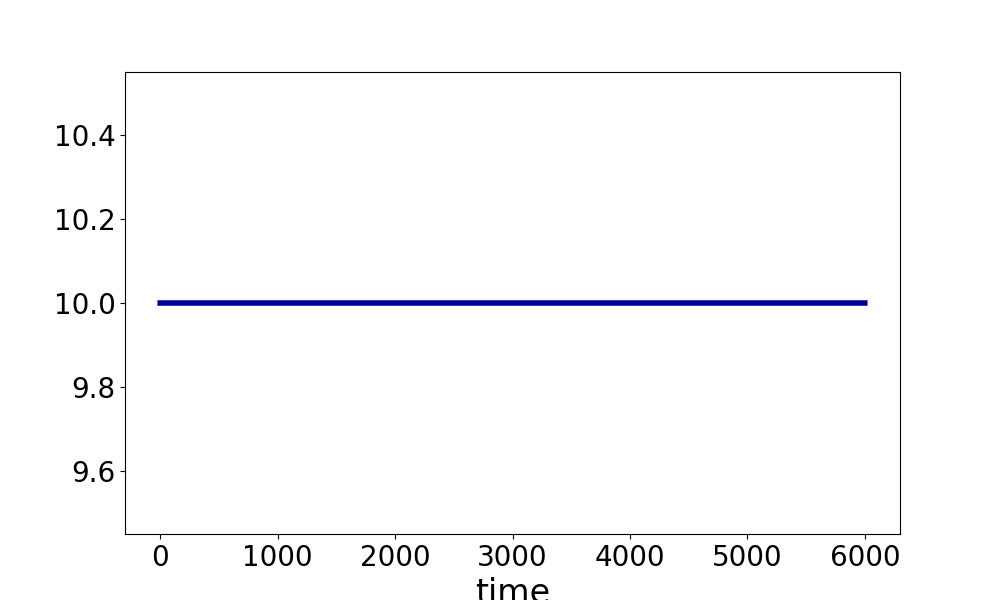

In [ ]:
cfg = ConfigurationWidget()       


cfg.display()

sol = SolutionWidget(config=cfg, result_transform=solution_to_fields_lenmatch_v3)
sol.display()



In [7]:
guiprocess = cfg.process
sim = Cadet()
sim.evaluate_stationarity=False
res = sim.simulate(guiprocess)

In [8]:
sol = SolutionWidget(config=cfg, result_transform=solution_to_fields_lenmatch_v3)
sol.display()



In [9]:
from CADETProcess.modelBuilder import CLR
from CADETProcess.processModel import LumpedRateModelWithoutPores, ComponentSystem
from CADETProcess.simulator import Cadet

cs = ComponentSystem(1)

column = LumpedRateModelWithoutPores(cs, "col")
column.length = 0.1
column.diameter = 0.01
column.axial_dispersion = 1e-8
column.total_porosity = 0.5

feed_c = 1
flow_rate = 1e-6
feed_duration = 10
recycle_off = 30
cycle_time = 100

#process = CLR(column, feed_c, flow_rate, feed_duration, recycle_off, cycle_time)

sim = Cadet()
sim.evaluate_stationarity=False
res = sim.simulate(guiprocess)



In [10]:
res.solution.GRM.outlet.solution


array([[ 0.00000000e+00],
       [-1.54484977e-94],
       [-3.11682710e-85],
       ...,
       [ 8.14468124e-16],
       [ 8.16929643e-16],
       [ 8.19391162e-16]])

(<Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='$time~/~min$', ylabel='$c~/~mM$'>)

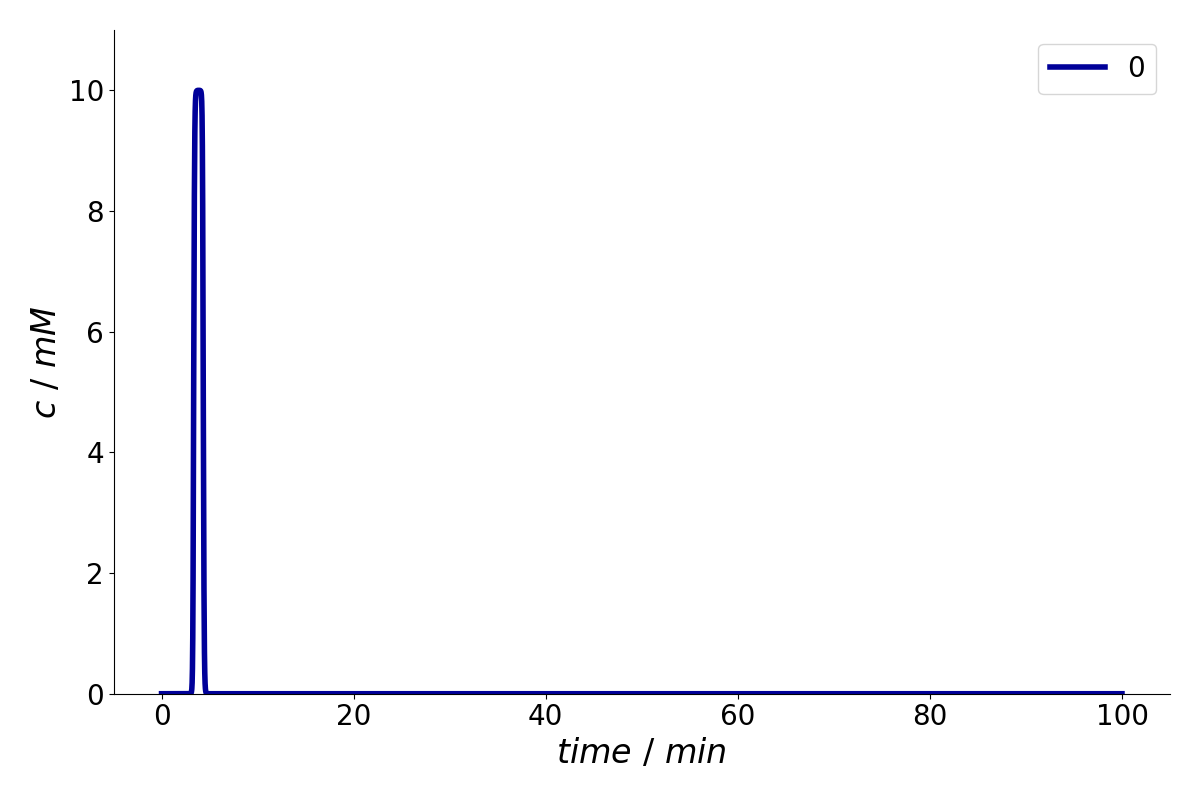

In [11]:
res = sim.simulate(guiprocess)
res.solution.GRM.outlet.plot()

In [ ]:
column.

['total_porosity',
 'length',
 'diameter',
 'axial_dispersion',
 'length',
 'diameter',
 'axial_dispersion']

In [20]:
res = sim.simulate(guiprocess)
res.solution

{'feed': {'inlet': <CADETProcess.solution.SolutionIO at 0x71b446fb1940>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x71b446fa7aa0>},
 'eluent': {'inlet': <CADETProcess.solution.SolutionIO at 0x71b446fc6120>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x71b446fc7710>},
 'GRM': {'inlet': <CADETProcess.solution.SolutionIO at 0x71b446fc75c0>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x71b446fb66f0>},
 'outlet': {'inlet': <CADETProcess.solution.SolutionIO at 0x71b446fb8650>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x71b446fbade0>}}

In [42]:
u, p = "GRM", "outlet"  # pick any unit/port you like

res = sim.simulate(guiprocess)
solmap = res.solution

print("solmap type:", type(solmap))
print("unit keys:", list(solmap.keys())[:10])

# --- TIME: try unit, then global
unit_time_obj = getattr(solmap[u], "time", None)
global_time_obj = getattr(solmap, "time", None)

def extract_values(x):
    if x is None: return None
    if isinstance(x, dict) and "values" in x: return x["values"]
    return getattr(x, "values", None) if hasattr(x, "values") else x

t_unit   = extract_values(unit_time_obj)
t_global = extract_values(global_time_obj)

print("unit time type:", type(t_unit))
print("global time type:", type(t_global))

import numpy as np
t = np.asarray(t_unit if t_unit is not None else t_global)
print("t.shape:", getattr(t, "shape", None))

# --- DATA
io = solmap[u][p]
data_obj = getattr(io, "solution", None)
data = np.asarray(getattr(data_obj, "values", data_obj))
print("data.shape:", getattr(data, "shape", None))


solmap type: <class 'addict.addict.Dict'>
unit keys: ['feed', 'eluent', 'GRM', 'outlet']
unit time type: <class 'builtin_function_or_method'>
global time type: <class 'builtin_function_or_method'>
t.shape: ()
data.shape: (101, 1)
